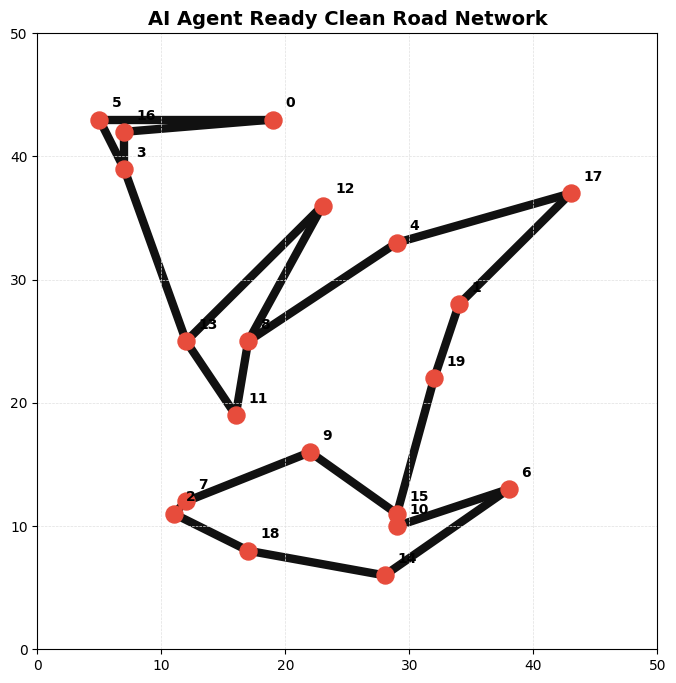

--- AI AGENT DATA INPUTS ---

1. AI Grid Shape: (50, 50) (0 = Building/Wall, 1 = Walkable Road)

2. Graph Adjacency List (Konsa chowk kis se connected hai):
   Intersection 0 (Pos: (np.int64(19), np.int64(43))) -> Connected to Roads: [np.int32(16), np.int32(5)]
   Intersection 1 (Pos: (np.int64(34), np.int64(28))) -> Connected to Roads: [np.int32(17), np.int32(19)]
   Intersection 2 (Pos: (np.int64(11), np.int64(11))) -> Connected to Roads: [np.int32(7), np.int32(18)]
   Intersection 3 (Pos: (np.int64(7), np.int64(39))) -> Connected to Roads: [np.int32(5), np.int32(16), np.int32(13)]
   Intersection 4 (Pos: (np.int64(29), np.int64(33))) -> Connected to Roads: [np.int32(8), np.int32(17)]


In [13]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import Delaunay

# --- CONFIGURATION ---
NUM_NODES = 20        # AI agent ke liye 20 nodes ka network samajhna aasan aur clear hota hai
MAP_SIZE = 50         # 50x50 ka grid size jo matrix mein convert ho sake
SEED = 42             # Fixed seed taake har baar same map bane aur agent test ho sake

def generate_ai_agent_friendly_map():
    random.seed(SEED)
    np.random.seed(SEED)

    # 1. Nodes ki coordinates generate karna
    points = []
    for _ in range(NUM_NODES):
        x = int(np.random.uniform(5, MAP_SIZE - 5))
        y = int(np.random.uniform(5, MAP_SIZE - 5))
        if [x, y] not in points:
            points.append([x, y])
    points = np.array(points)

    # 2. Planar Graph (Delaunay) taake clear non-overlapping raste banein
    tri = Delaunay(points)
    G = nx.Graph()

    for i, p in enumerate(points):
        G.add_node(i, pos=(p[0], p[1]))

    for path in tri.simplices:
        G.add_edge(path[0], path[1])
        G.add_edge(path[1], path[2])
        G.add_edge(path[2], path[0])

    # Extra edges remove karna clear grid look ke liye
    edges = list(G.edges())
    random.shuffle(edges)
    for u, v in edges:
        if G.degree(u) > 2 and G.degree(v) > 2:
            G.remove_edge(u, v)
            if not nx.is_connected(G):
                G.add_edge(u, v)

    # 3. AI Agent Grid Array (0 = No Road/Obstacle, 1 = Clear Road)
    # Yeh AI matrix vision/grid-based agents ke liye hai
    ai_grid = np.zeros((MAP_SIZE, MAP_SIZE), dtype=int)
    positions = nx.get_node_attributes(G, 'pos')

    # Grid par roads draw karna (Bresenham's Line Algorithm ki tarah grids ko connect karna)
    for u, v in G.edges():
        x1, y1 = positions[u]
        x2, y2 = positions[v]

        # Simple line rasterization grid ke liye
        num_pts = max(abs(x2 - x1), abs(y2 - y1)) * 2
        for t in np.linspace(0, 1, int(num_pts)):
            xi = int(round(x1 + t * (x2 - x1)))
            yi = int(round(y1 + t * (y2 - y1)))
            if 0 <= xi < MAP_SIZE and 0 <= yi < MAP_SIZE:
                ai_grid[yi, xi] = 1 # 1 Matlab Clear Road

    # 4. GRAPHICAL VISUALIZATION (Insaan aur AI Image Mode ke liye)
    fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')
    ax.set_facecolor('#FFFFFF')

    # Roads ko bilkul clean black lines mein dikhana (Computer Vision models easily track kar sakte hain)
    for u, v in G.edges():
        x1, y1 = positions[u]
        x2, y2 = positions[v]
        ax.plot([x1, x2], [y1, y2], color='#111111', linewidth=6, solid_capstyle='round', zorder=1)

    # Nodes (Chowk/Intersections)
    for node, (x, y) in positions.items():
        ax.scatter(x, y, color='#E74C3C', s=150, zorder=2) # Red dots for intersections
        ax.text(x + 1, y + 1, str(node), fontsize=10, weight='bold', color='black', zorder=3)

    ax.set_xlim(0, MAP_SIZE)
    ax.set_ylim(0, MAP_SIZE)
    ax.set_title("AI Agent Ready Clean Road Network", fontsize=14, weight='bold')
    ax.axis('on') # Grid coordinate ticks on rakhe hain taake pixels ka andaza ho
    plt.grid(True, color='#E0E0E0', linestyle='--', linewidth=0.5)
    plt.show()

    # 5. AI AGENT DATA OUTPUTS
    print("--- AI AGENT DATA INPUTS ---")
    print(f"\n1. AI Grid Shape: {ai_grid.shape} (0 = Building/Wall, 1 = Walkable Road)")

    # Ek chota snippet dikhane ke liye matrix ka
    print("\n2. Graph Adjacency List (Konsa chowk kis se connected hai):")
    adjacency_dict = nx.to_dict_of_lists(G)
    for node, neighbors in list(adjacency_dict.items())[:5]:
        print(f"   Intersection {node} (Pos: {positions[node]}) -> Connected to Roads: {neighbors}")

    return ai_grid, G, positions

# Execution
if __name__ == "__main__":
    grid, graph, nodes_pos = generate_ai_agent_friendly_map()